In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA


import math

In [5]:
url = 'heart.csv'
df = pd.read_csv(url)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Check for Missing Data
missing_cols = df.isna().any()
if missing_cols.any():
    cols_with_missing = missing_cols[missing_cols].index
    for col in cols_with_missing:
        print(f"Data Missing in {col}")
else:
    print("No Missing Data in Any Column")

No Missing Data in Any Column


In [7]:
target = 'target'
features = [col for col in df.columns if col != target and col]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [9]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")


Numeric Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical Features: []


In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=10)), # We'll start by reducing to 10 components
    ('model', LogisticRegression(max_iter=1000)) 
])

pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with 10 PCA components: {accuracy:.4f}")


Accuracy with 10 PCA components: 0.7961


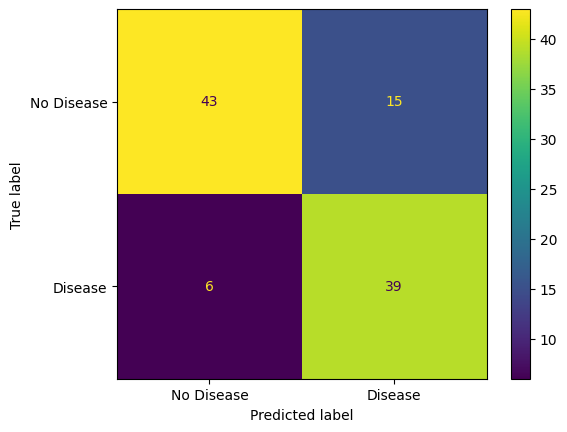

In [15]:
class_names = ['No Disease', 'Disease']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

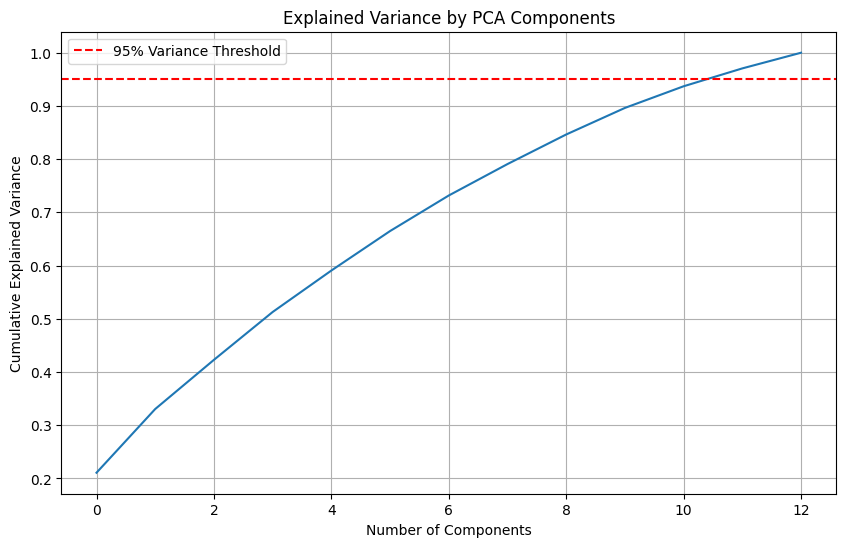

In [17]:
pca_analyzer_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA()) # Use PCA with all components to analyze them
])
pca_analyzer_pipe.fit(X_train)
pca_components = pca_analyzer_pipe.named_steps['pca']

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_components.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
# Add a line for 95% variance, a common threshold
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.show()


In [18]:
# Find how many components are needed for 95% variance
variance_ratios = pca_components.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratios)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to retain 95% of variance: {n_components_95}")


Number of components needed to retain 95% of variance: 12


In [21]:
sample = X_test.head(1)
prediction = pipe.predict(sample)[0]
actual = y_test.head(1).values[0]

# print(sample)
print(f"\nPredicted Outcome: {'Heart Disease' if prediction == 1 else 'No Heart Disease'}")
print(f"Actual Outcome:    {'Heart Disease' if actual == 1 else 'No Heart Disease'}")



Predicted Outcome: Heart Disease
Actual Outcome:    Heart Disease
